##############################################################################
##############################################################################
#                              SERIES TEMPORAIS                              #
##############################################################################
##############################################################################

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


from ipynb.fs.defs.Series_Temporais import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

# Agora você pode usar normalmente no seu código

###############################################################################
###############################################################################
### Metodos SIMPLES de Previsao de Series Temporais
###############################################################################
###############################################################################

In [31]:
# Serie - Exemplo
 
serie = np.array([3, 5, 9, 20, 12, 17, 22, 23, 51, 41, 56, 75, 60, 75, 88])

In [32]:
# Funcao para realizar previsao naive e calcular intervalos de confianca 
# ajustados

def naive_forecast(time_series, h=3, confidence_level=0.95):
    # A ultima observacao da serie
    last_observation = time_series[-1]
    
    # Previsoes naive para h passos a  frente
    forecasts = np.array([last_observation] * h)
    
    # Calculando os erros de previsao
    errors = time_series[1:] - time_series[:-1] 
    erro2=errors*errors
    std_error =np.sqrt(erro2.mean())  # Desvio dos erros
    
    # Valor cri­tico da distribuicao normal para o ni­vel de confianca desejado
    z_value = stats.norm.ppf((1 + confidence_level) / 2)
    
    # Calculando os intervalos de confianca com ajuste para h passos a  frente
    confidence_intervals = [
        (forecast - z_value * std_error * np.sqrt(step+1), 
         forecast + z_value * std_error * np.sqrt(step+1))
        for step, forecast in enumerate(forecasts)
    ]
    
    # Criando um DataFrame para armazenar previsoes e intervalos de confianca
    forecast_df = pd.DataFrame({
        "Previsao": forecasts,
        "IC Inferior": [ci[0] for ci in confidence_intervals],
        "IC Superior": [ci[1] for ci in confidence_intervals]
    }, index=[f'T+{i+1}' for i in range(h)])
    
    return forecast_df, confidence_intervals

In [33]:
# In[65]: Funcao para plotar a serie temporal com previsoes e intervalos de confianca 
def plot_naive_forecast(time_series, forecast_df):
    n = len(time_series)
    h = len(forecast_df)
    
    plt.figure(figsize=(10, 6))
    
    # Plotando os valores reais da serie temporal
    plt.plot(range(n), time_series, label='Serie Temporal', color='blue')
    
    # Plotando os valores previstos
    plt.plot(range(n-1, n+h), np.concatenate(([time_series[-1]], 
                                              forecast_df['Previsao'])), 
             label='Previsao (Naive)', linestyle='--', marker='o', color='orange')

    # Plotando os limites inferior e superior dos intervalos de confianca
    plt.plot(range(n, n+h), forecast_df['IC Inferior'], 
             label='IC Inferior (95%)', linestyle='--', color='red')
    plt.plot(range(n, n+h), forecast_df['IC Superior'],
             label='IC Superior (95%)', linestyle='--', color='green')

    # Adicionando ro­tulos e legendas
    plt.title('Previsao Naive com Intervalos de Confianca (95%)')
    plt.xlabel('Tempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True)
    
    # Exibindo o grafico
    plt.show()

     Previsao  IC Inferior  IC Superior
T+1        88    62.633795   113.366205
T+2        88    52.126769   123.873231
T+3        88    44.064444   131.935556


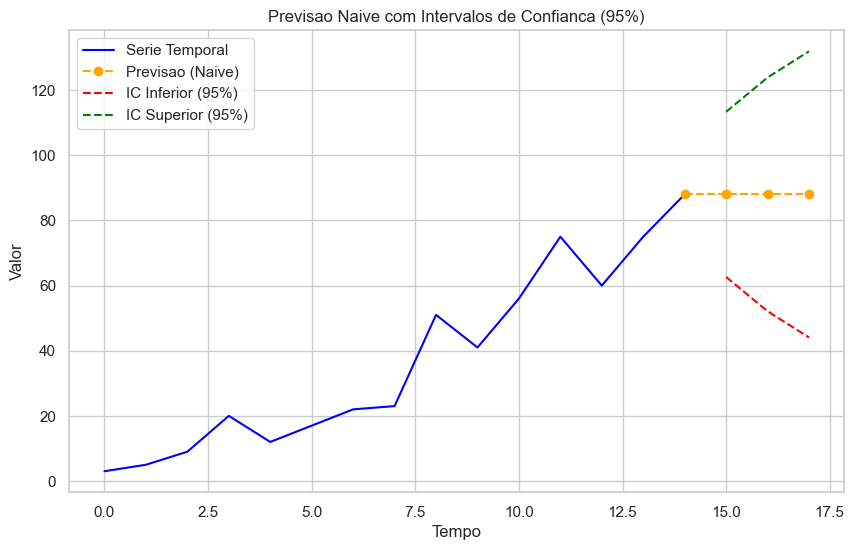

In [34]:
# In[66]: Aplicando a previsao naive com intervalos de confianca ajustados
naiveforecast_df, confidence_intervals = naive_forecast(serie, h=3)

# Mostrando o DataFrame com previsoes
print(naiveforecast_df)

# Plotando os resultados com previsoes e intervalos de confianca como linhas
plot_naive_forecast(serie, naiveforecast_df)

###----------------------Estatísticas de Erro ----------------

In [39]:
reais = serie[1:]  # Valores reais a partir do segundo ponto
previstos = serie[:-1]  # Previsão Naive (valor anterior)

In [40]:
# Cálculos de Erro
erro = reais - previstos
merror = np.mean(erro)
mae = mean_absolute_error(reais, previstos)
rmse = root_mean_squared_error(reais, previstos)
mpe = np.mean((reais - previstos) / reais) * 100
mape = mean_absolute_percentage_error(reais, previstos) * 100

In [41]:
# Coeficiente de desigualdade de Theil (U)
# Mede a acurácia relativa: U < 1 indica que a previsão é melhor que o caminho aleatório
theil = np.sqrt(np.mean(erro**2)) / (np.sqrt(np.mean(reais**2)) + np.sqrt(np.mean(previstos**2)))

In [42]:
# --- Exibição dos Resultados ---

print("\nIndicadores de Acuracia")
print(f'ME - Mean Error: {merror:.2f}')
print(f'MAE - Mean Absolute Error: {mae:.2f}')
print(f'RMSE - Raiz Quadrada do Erro Medio: {rmse:.2f}')
print(f'MPE - Mean Percentage Error: {mpe:.2f}%')
print(f'MAPE - Mean Absolute Percentage Error: {mape:.2f}%')
print(f'THEIL_U - Theils Inequality Coefficient: {theil:.4f}')


Indicadores de Acuracia
ME - Mean Error: 6.07
MAE - Mean Absolute Error: 10.79
RMSE - Raiz Quadrada do Erro Medio: 12.94
MPE - Mean Percentage Error: 15.83%
MAPE - Mean Absolute Percentage Error: 32.41%
THEIL_U - Theils Inequality Coefficient: 0.1448


In [ ]:
##############################################################################################################################################################
### Metodo de previsao pela MEDIA 
##############################################################################################################################################################

Resultados da Previsão
------------------------------
Previsão:                           37.13
Limite inferior do intervalo de confiança: -25.77
Limite superior do intervalo de confiança: 100.04
------------------------------


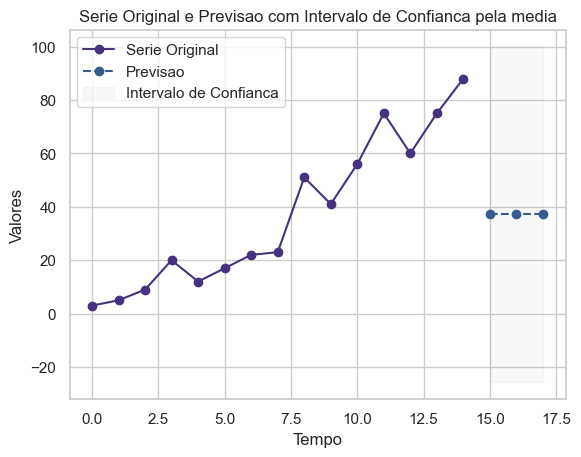

In [43]:

# Funcao para realizar previsao pela media e calcular intervalos de confianca 

def forecast_with_mean(time_series, steps_ahead, confidence=0.95):
    # Calcular a media da serie
    mean_series = np.mean(time_series)
    
    # Calcular os erros (resi­duos) da previsao pela media
    errors = time_series - mean_series
    
    # Calcular o desvio padrao dos erros
    std_errors = np.std(errors, ddof=1)
    
    # Prever com base na media
    forecast = [mean_series] * steps_ahead

    # Calcular intervalo de confianca usando o desvio padrao dos erros
    n = len(time_series)
    alpha = 1 - confidence
    t_value = stats.t.ppf(1 - alpha/2, df=n-1)  
    margin_of_error = t_value * std_errors*np.sqrt(1+1/len(time_series))
    
    # Inferior e superior
    lower_bound = [mean_series - margin_of_error] * steps_ahead
    upper_bound = [mean_series + margin_of_error] * steps_ahead

    return forecast, lower_bound, upper_bound

# In[68]: Funcao para plotar a serie original e a previsao
def plot_forecast_with_mean(time_series, forecast, lower_bound,
                                            upper_bound, steps_ahead):
    # Plotar a serie original
    plt.plot(range(len(time_series)), time_series, label="Serie Original", 
             marker='o')
    
    # Criar eixo de tempo para previsao
    forecast_range = range(len(time_series), len(time_series) + steps_ahead)
    
    # Plotar a previsao
    plt.plot(forecast_range, forecast, label="Previsao", marker='o', 
             linestyle='--')
    
    # Plotar intervalo de confianca
    plt.fill_between(forecast_range, lower_bound, upper_bound, color='gray',
                     alpha=0.05, label='Intervalo de Confianca')
    
    # Detalhes do grafico
    plt.xlabel("Tempo")
    plt.ylabel("Valores")
    plt.legend()
    plt.title("Serie Original e Previsao com Intervalo de Confianca pela media")
    plt.show()

# In[69]: Definir numero de passos a  frente
h = 3

# Gerar previsao e intervalos de confianca
forecast_mean, lower_bound, upper_bound = forecast_with_mean(serie, h)

forecast_mean

# In[70]: Exibir resultados

print("Resultados da Previsão")
print("-" * 30)
# Usamos [0] para pegar o primeiro valor da lista de previsões
print(f"Previsão:                           {forecast_mean[0]:.2f}")
print(f"Limite inferior do intervalo de confiança: {lower_bound[0]:.2f}")
print(f"Limite superior do intervalo de confiança: {upper_bound[0]:.2f}")
print("-" * 30)


# In[71]: Chamar a funcao de plotagem
plot_forecast_with_mean(serie, forecast_mean, lower_bound, upper_bound, h)


##############################################################################################################################################################
### Metodo de previsao com DRIFT
##############################################################################################################################################################

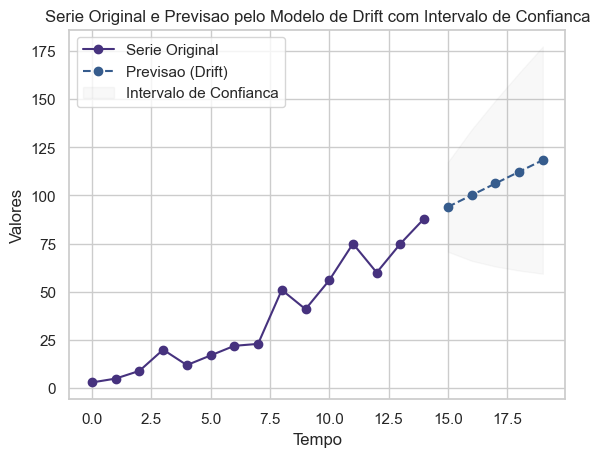

In [44]:

# Funcao para calcular a previsao pelo modelo de Drift
def drift_forecast(time_series, steps_ahead, confidence=0.95):
    n = len(time_series)
    
    # Previsao pelo modelo de drift
    drift = (time_series[-1] - time_series[0]) / (n - 1)
    forecast = [time_series[-1] + (i + 1) * drift for i in range(steps_ahead)]
    
    # Calculo dos erros 
    predicted_values = []
    for i in range(1, n):
        predicted_values.append(time_series[i-1] + drift)
    
    # Calcular os erros como a diferenca entre os valores reais e os previstos
    errors = time_series[1:] - np.array(predicted_values)
    erro2=errors*errors
   
    # Calcular o desvio dos erros
    std_errors = np.sqrt(erro2.mean())
 
    # variavel auxiliar para o intervalo de confianca
    calc = len(errors)
  
    # Calcular intervalo de confianca usando o desvio padrao dos erros
    z_value = stats.norm.ppf((1 + confidence) / 2)
   
    # Limites inferior e superior
    lower_bound = [forecast[i] -
                   z_value * std_errors * np.sqrt((i+1)*(1+(i+1)/(calc -1)))
                   for i in range(steps_ahead)]
    upper_bound = [forecast[i] +
                   z_value * std_errors * np.sqrt((i+1)*(1+(i+1)/(calc -1))) 
                   for i in range(steps_ahead)]
        
    return forecast, lower_bound, upper_bound

# In[73]: Funcao para plotar a serie original e a previsao pelo modelo de Drift
def plot_forecast_with_drift(time_series, forecast, lower_bound,
                                            upper_bound, steps_ahead):
    # Plotar a serie original
    plt.plot(range(len(time_series)), time_series, label="Serie Original",
             marker='o')
    
    # Criar eixo de tempo para previsao
    forecast_range = range(len(time_series), len(time_series) + steps_ahead)
    
    # Plotar a previsao
    plt.plot(forecast_range, forecast, label="Previsao (Drift)", marker='o', 
             linestyle='--')
    
    # Plotar intervalo de confianca
    plt.fill_between(forecast_range, lower_bound, upper_bound, color='gray', 
                     alpha=0.05, label='Intervalo de Confianca')
    
    # Detalhes do grafico
    plt.xlabel("Tempo")
    plt.ylabel("Valores")
    plt.legend()
    plt.title("Serie Original e Previsao pelo Modelo de Drift com Intervalo de Confianca")
    plt.show()

# In[74]: Definir numero de passos a  frente
h = 5

# Gerar previsao e intervalos de confianca pelo modelo de Drift
forecast_drift, lower_bound, upper_bound = drift_forecast(serie, h)

forecast_drift
lower_bound
upper_bound

# Chamar a funcao de plotagem
plot_forecast_with_drift(serie, forecast_drift, lower_bound, upper_bound, h)



##############################################################################################################################################################
### Metodo de previsao com NAIVE SAZONAL
##############################################################################################################################################################

         mes  passengers
0 2007-01-01         112
1 2007-02-01         118
2 2007-03-01         132
3 2007-04-01         129
4 2007-05-01         121


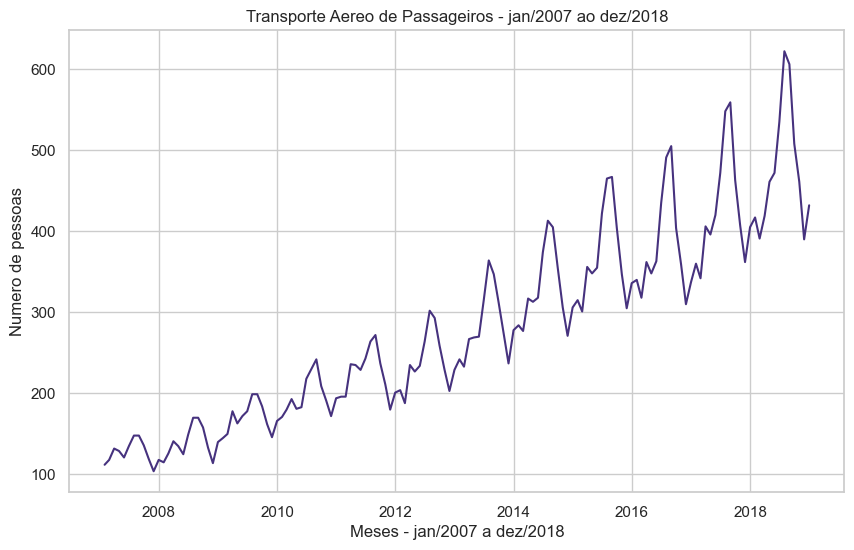

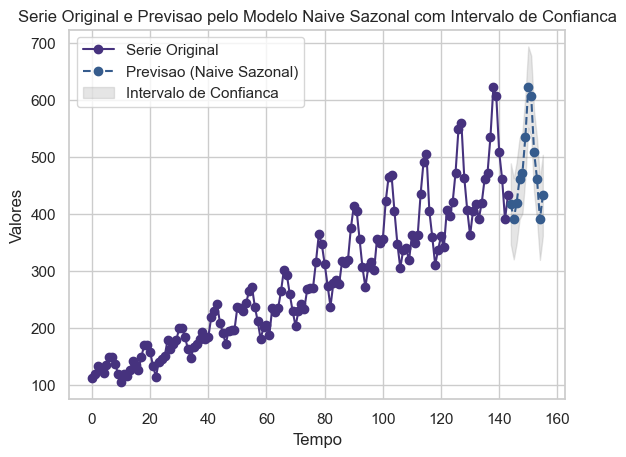

In [46]:
###############################################################################
### Metodo de previsao com NAIVE SAZONAL
###############################################################################

# Funcao para rodar o modelo Naive Sazonal com intervalos de confianca
def seasonal_naive_forecast(time_series, season_length, steps_ahead, confidence=0.95):
    """
    time_series: Série temporal
    season_length: Período sazonal (ex: 12 meses para sazonalidade mensal)
    steps_ahead: O número de períodos à frente para previsão
    confidence: Nível de confiança (95% por padrão)
    """
    # Prever o valor com base na sazonalidade anterior
    forecast = [time_series.iloc[-season_length + i] for i in range(steps_ahead)]
    
    # Previsão dos valores dentro da série histórica para obter resíduos
    predicted_values = [time_series.iloc[i - season_length] for i in range(season_length, len(time_series))]
  
    # Calcular os erros residuais
    residuals = time_series.iloc[season_length:] - np.array(predicted_values)
    
    # Calcular o quadrado dos erros (resíduos)
    errors2 = residuals ** 2
    
    # Calcular o desvio padrão dos erros
    std_residuals = np.sqrt(errors2.mean())
 
    # Calcular o valor crítico z para o intervalo de confiança
    z_value = stats.norm.ppf((1 + confidence) / 2)
    
    # Calcular a margem de erro
    margin_of_error = z_value * std_residuals
    
    # Definir limites inferiores e superiores dos intervalos de confiança
    lower_bound = [forecast[i] - margin_of_error * np.sqrt((i // season_length) + 1) for i in range(steps_ahead)]
    upper_bound = [forecast[i] + margin_of_error * np.sqrt((i // season_length) + 1) for i in range(steps_ahead)]
    
    return forecast, lower_bound, upper_bound

# In[76]: Funcao para plotar a serie original, previsao e intervalos de confianca
def plot_seasonal_naive_forecast(time_series, forecast, lower_bound,
                                 upper_bound, steps_ahead):
    # Plotar a serie original
    plt.plot(range(len(time_series)), time_series, label="Serie Original",
             marker='o')
    
    # Criar eixo de tempo para previsao
    forecast_range = range(len(time_series), len(time_series) + steps_ahead)
    
    # Plotar a previsao
    plt.plot(forecast_range, forecast, label="Previsao (Naive Sazonal)", 
             marker='o', linestyle='--')
    
    # Plotar intervalo de confianca
    plt.fill_between(forecast_range, lower_bound, upper_bound, color='gray',
                     alpha=0.2, label='Intervalo de Confianca')
    
    # Detalhes do grafico
    plt.xlabel("Tempo")
    plt.ylabel("Valores")
    plt.legend()
    plt.title("Serie Original e Previsao pelo Modelo Naive Sazonal com Intervalo de Confianca")
    plt.show()

# In[77]: Importando a base de dados
# pip install --upgrade openpyxl

airp = pd.read_excel("airpassengers.xlsx")

# Lendo a base de dados
print(airp.head())

# In[78]: Definindo a serie temporal com frequencia mensal
airpas = pd.Series(airp.iloc[:, 1].values, 
                    index=pd.date_range(start='2007-01-01', periods=len(airp), 
                                        freq='ME'))

# In[79]: Plotando o grafico
plt.figure(figsize=(10, 6))
plt.plot(airpas)
plt.title("Transporte Aereo de Passageiros - jan/2007 ao dez/2018")
plt.xlabel("Meses - jan/2007 a dez/2018")
plt.ylabel("Numero de pessoas")
plt.grid(True)
plt.show()

# In[80]: Definir os parametros de sazonalidade e numero de passos a  frente
season_length = 12  # Por exemplo, 12 meses para sazonalidade anual
steps_ahead = 12  # Prevendo os proximos 12 peri­odos (um ano a  frente - h)

# In[81]: Gerar previsao e intervalos de confianca pelo modelo Naive Sazonal
forecast, lower_bound, upper_bound = seasonal_naive_forecast(airpas, 
                                                season_length, steps_ahead)

forecast
lower_bound
upper_bound

# Chamar a funcao de plotagem
plot_seasonal_naive_forecast(airpas, forecast, lower_bound, upper_bound, 
                             steps_ahead)


# In[82]:


###############################################################################
### Modelos de SUAVIZACAO EXPONENCIAL - Simples
###############################################################################